# Аналіз факторного експерименту NetLogo

Notebook аналізує результати BehaviourSpace Table output для моделі впливу винагороди на цільову поведінку, внутрішню мотивацію та звичку.

Він виконує:

- завантаження й очищення CSV;
- перевірку факторного дизайну;
- описову статистику;
- аналіз головних ефектів;
- heatmap та interaction plots;
- factorial ANOVA;
- Random Forest і permutation importance;
- пошук сценаріїв зі стабільним crowding-out;
- експорт таблиць і графіків.

## Підготовка середовища

```bash
python -m pip install pandas numpy matplotlib scikit-learn statsmodels
```

У notebook використовується `n_jobs=1`, щоб уникнути проблем `joblib/loky` на macOS із Python 3.13.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/igor/projects/phd/reward-habits-model/analysis_output


## Налаштування

In [2]:
CSV_PATH = Path("./experiments/2/reward-habits-controlled-factored-experiment-table.csv")

PARAMETERS = [
    "low-reward",
    "high-reward",
    "crowding-out-rate",
    "habit-learning-rate",
]

PRIMARY_TARGET = "high-reward-crowding-out-effect"
SECONDARY_TARGET = "low-reward-persistence-effect"

WITHDRAWAL_RATES = [
    'choice-rate "control" "withdrawal"',
    'choice-rate "low-salience" "withdrawal"',
    'choice-rate "high-salience" "withdrawal"',
]

MOTIVATION_METRICS = [
    'mean-intrinsic-motivation "control"',
    'mean-intrinsic-motivation "low-salience"',
    'mean-intrinsic-motivation "high-salience"',
]

HABIT_METRICS = [
    'mean-habit "control"',
    'mean-habit "low-salience"',
    'mean-habit "high-salience"',
]

## Завантаження NetLogo Table output

Функція автоматично знаходить рядок із `[run number]`, тому службові рядки BehaviourSpace не заважають читанню CSV.

In [3]:
df = pd.read_csv(CSV_PATH, skiprows=6)

print("Shape:", df.shape)
for column in df.columns:
    print("-", column)

df.head()

Shape: (1620, 17)
- [run number]
- low-reward
- high-reward
- crowding-out-rate
- habit-learning-rate
- [step]
- high-reward-crowding-out-effect
- low-reward-persistence-effect
- choice-rate "control" "withdrawal"
- choice-rate "low-salience" "withdrawal"
- choice-rate "high-salience" "withdrawal"
- mean-intrinsic-motivation "control"
- mean-intrinsic-motivation "low-salience"
- mean-intrinsic-motivation "high-salience"
- mean-habit "control"
- mean-habit "low-salience"
- mean-habit "high-salience"


,[run number],low-reward,high-reward,crowding-out-rate,habit-learning-rate,[step],high-reward-crowding-out-effect,low-reward-persistence-effect,"choice-rate ""control"" ""withdrawal""","choice-rate ""low-salience"" ""withdrawal""","choice-rate ""high-salience"" ""withdrawal""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience"""
0,5,0.2,0.7,0.01,0.005,150,0.057259,0.058460,0.567116,0.625576,0.624374,0.512192,0.555150,0.476816,0.187284,0.287045,0.383660
1,1,0.2,0.7,0.01,0.005,150,0.052775,0.062384,0.557335,0.619720,0.610110,0.502977,0.544844,0.459447,0.166805,0.272276,0.372100
2,8,0.2,0.7,0.01,0.005,150,0.100163,0.070333,0.537475,0.607808,0.637638,0.487844,0.540625,0.484695,0.150948,0.259482,0.411030
3,9,0.2,0.7,0.01,0.005,150,0.077494,0.057474,0.555539,0.613013,0.633033,0.498427,0.544679,0.482609,0.167763,0.273208,0.401484
4,4,0.2,0.7,0.01,0.005,150,0.067077,0.054965,0.569910,0.624875,0.636987,0.512637,0.546550,0.486346,0.190146,0.280968,0.405333


## Перевірка структури

In [4]:
required_columns = (
    ["[run number]"]
    + PARAMETERS
    + [PRIMARY_TARGET, SECONDARY_TARGET]
    + WITHDRAWAL_RATES
    + MOTIVATION_METRICS
    + HABIT_METRICS
)

missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    print("Відсутні колонки:")
    for column in missing_columns:
        print("-", column)
else:
    print("Усі очікувані колонки присутні.")

Усі очікувані колонки присутні.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 17 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   [run number]                               1620 non-null   int64  
 1   low-reward                                 1620 non-null   float64
 2   high-reward                                1620 non-null   float64
 3   crowding-out-rate                          1620 non-null   float64
 4   habit-learning-rate                        1620 non-null   float64
 5   [step]                                     1620 non-null   int64  
 6   high-reward-crowding-out-effect            1620 non-null   float64
 7   low-reward-persistence-effect              1620 non-null   float64
 8   choice-rate "control" "withdrawal"         1620 non-null   float64
 9   choice-rate "low-salience" "withdrawal"    1620 non-null   float64
 10  choice-rate "high-salien

## Очищення даних

In [6]:
analysis_columns = (
    PARAMETERS
    + [PRIMARY_TARGET, SECONDARY_TARGET]
    + WITHDRAWAL_RATES
    + MOTIVATION_METRICS
    + HABIT_METRICS
)

clean_df = df.copy()

for column in analysis_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

before_rows = len(clean_df)
clean_df = clean_df.dropna(
    subset=PARAMETERS + [PRIMARY_TARGET, SECONDARY_TARGET]
).copy()

print("Rows before:", before_rows)
print("Rows after:", len(clean_df))
print("Removed:", before_rows - len(clean_df))

Rows before: 1620
Rows after: 1620
Removed: 0


## Перевірка факторного дизайну

In [7]:
design_counts = (
    clean_df.groupby(PARAMETERS)
    .size()
    .reset_index(name="repetitions")
)

print("Combinations:", len(design_counts))
print("Minimum repetitions:", design_counts["repetitions"].min())
print("Maximum repetitions:", design_counts["repetitions"].max())

if design_counts["repetitions"].nunique() == 1:
    print("Дизайн збалансований.")
else:
    print("Увага: дизайн незбалансований.")

design_counts.head()

Combinations: 81
Minimum repetitions: 20
Maximum repetitions: 20
Дизайн збалансований.


,low-reward,high-reward,crowding-out-rate,habit-learning-rate,repetitions
0,0.2,0.7,0.01,0.005,20
1,0.2,0.7,0.01,0.020,20
2,0.2,0.7,0.01,0.050,20
3,0.2,0.7,0.03,0.005,20
4,0.2,0.7,0.03,0.020,20


## Описова статистика

In [8]:
summary_metrics = [
    PRIMARY_TARGET,
    SECONDARY_TARGET,
    *WITHDRAWAL_RATES,
    *MOTIVATION_METRICS,
    *HABIT_METRICS,
]

clean_df[summary_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
high-reward-crowding-out-effect,1620.0,-0.053620,0.075967,-0.227104,-0.113908,-0.041854,0.003903,0.100163
low-reward-persistence-effect,1620.0,0.051577,0.021226,-0.001273,0.033078,0.052958,0.066978,0.114447
"choice-rate ""control"" ""withdrawal""",1620.0,0.697487,0.103758,0.527495,0.561365,0.741168,0.792665,0.810479
"choice-rate ""low-salience"" ""withdrawal""",1620.0,0.749065,0.087694,0.592793,0.634097,0.796446,0.820383,0.841241
"choice-rate ""high-salience"" ""withdrawal""",1620.0,0.643867,0.106338,0.378879,0.587062,0.640916,0.743806,0.799149
"mean-intrinsic-motivation ""control""",1620.0,0.500160,0.008267,0.473536,0.494565,0.500273,0.505459,0.534372
"mean-intrinsic-motivation ""low-salience""",1620.0,0.544397,0.011558,0.509353,0.536157,0.543854,0.552669,0.581421
"mean-intrinsic-motivation ""high-salience""",1620.0,0.337960,0.100857,0.149155,0.250744,0.380789,0.420859,0.493856
"mean-habit ""control""",1620.0,0.647824,0.342147,0.138614,0.179963,0.811623,0.958886,0.965359
"mean-habit ""low-salience""",1620.0,0.721781,0.297319,0.237066,0.329999,0.891151,0.969017,0.973908


## Частота crowding-out

Crowding-out фіксується, коли `high-reward-crowding-out-effect < 0`.

In [9]:
crowding_share = (clean_df[PRIMARY_TARGET] < 0).mean()
positive_persistence_share = (clean_df[SECONDARY_TARGET] > 0).mean()

print(f"Частка запусків із crowding-out: {crowding_share:.1%}")
print(f"Частка запусків із позитивним low-reward persistence: {positive_persistence_share:.1%}")

Частка запусків із crowding-out: 72.5%
Частка запусків із позитивним low-reward persistence: 99.9%


## Розподіл основних KPI

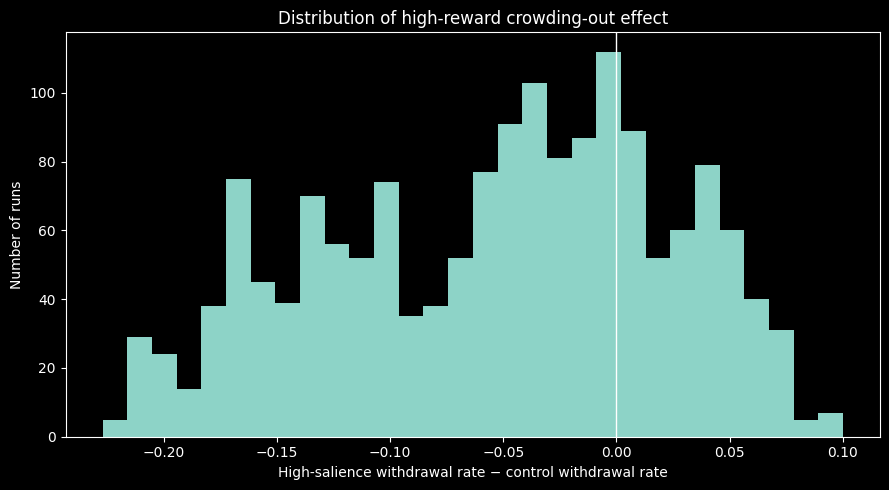

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(clean_df[PRIMARY_TARGET], bins=30)
ax.axvline(0, linewidth=1)
ax.set_title("Distribution of high-reward crowding-out effect")
ax.set_xlabel("High-salience withdrawal rate − control withdrawal rate")
ax.set_ylabel("Number of runs")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "distribution_high_reward_crowding_out.png", dpi=200)
plt.show()

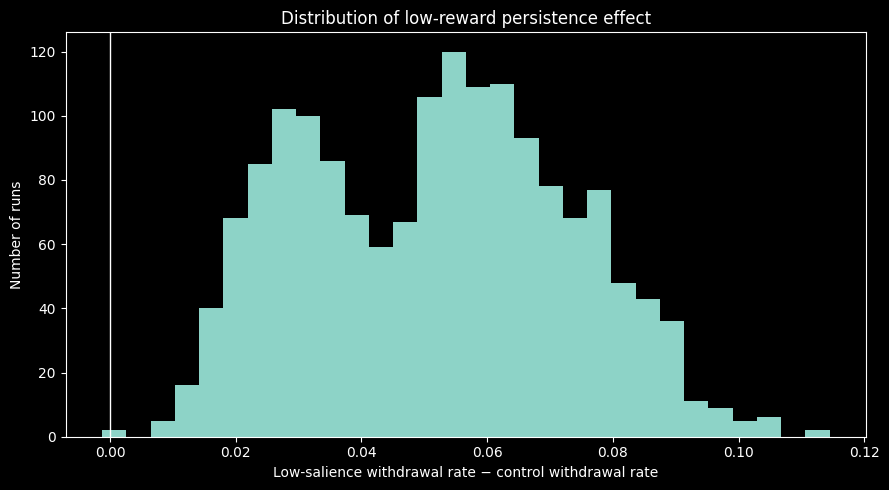

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(clean_df[SECONDARY_TARGET], bins=30)
ax.axvline(0, linewidth=1)
ax.set_title("Distribution of low-reward persistence effect")
ax.set_xlabel("Low-salience withdrawal rate − control withdrawal rate")
ax.set_ylabel("Number of runs")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "distribution_low_reward_persistence.png", dpi=200)
plt.show()

## Головні ефекти параметрів

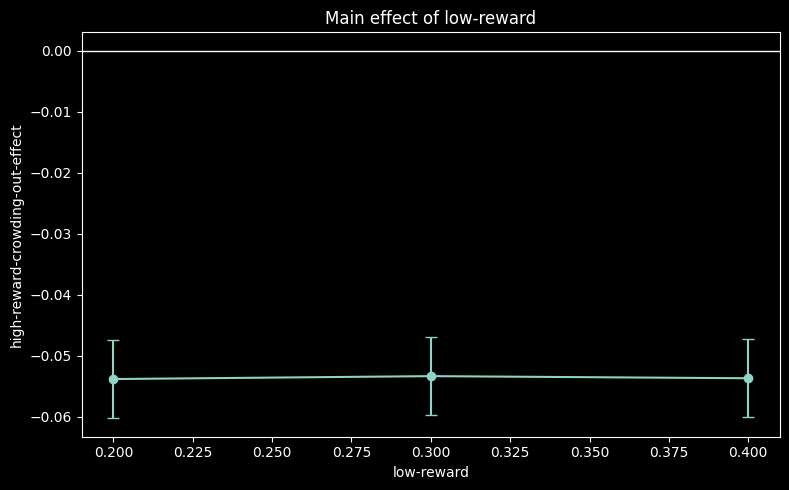

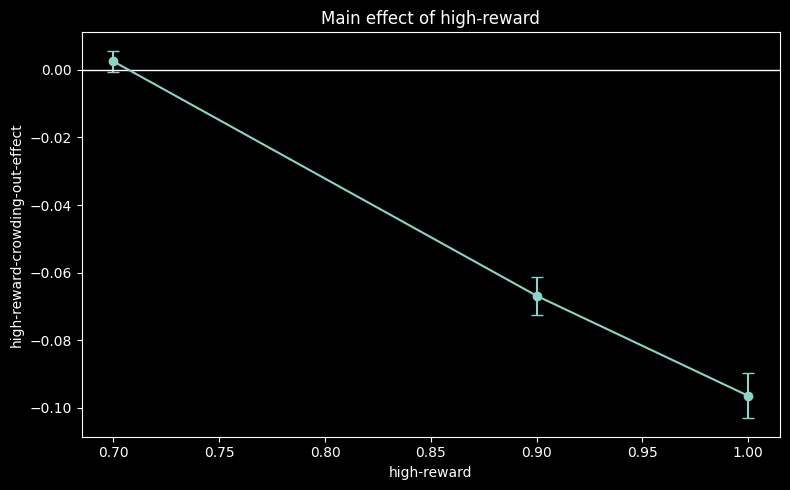

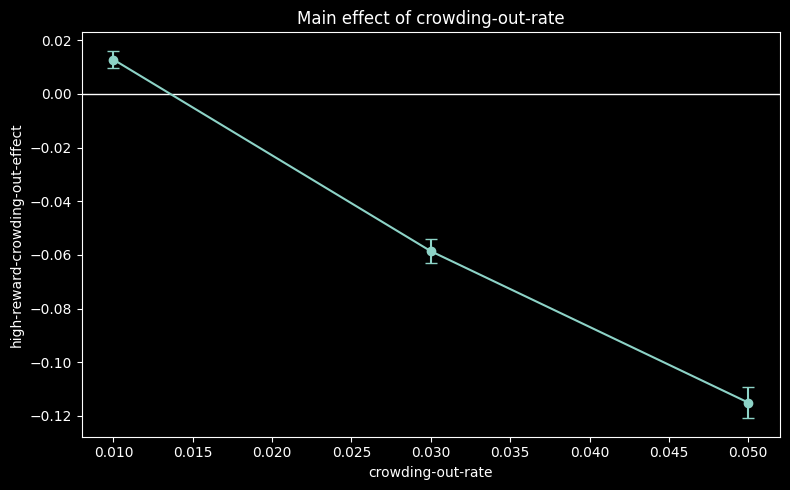

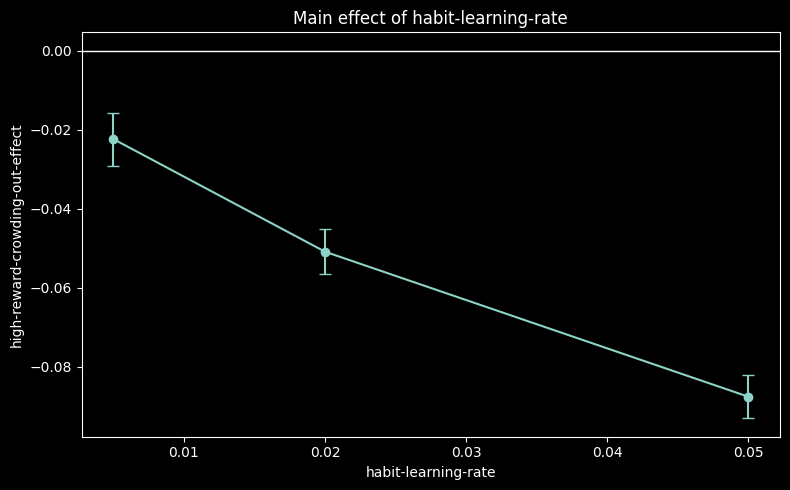

In [12]:
def main_effect_table(data, parameter, target):
    result = (
        data.groupby(parameter)[target]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    result["se"] = result["std"] / np.sqrt(result["count"])
    result["ci95"] = 1.96 * result["se"]
    return result


def plot_main_effect(data, parameter, target):
    result = main_effect_table(data, parameter, target)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        result[parameter],
        result["mean"],
        yerr=result["ci95"],
        marker="o",
        capsize=4,
    )
    ax.axhline(0, linewidth=1)
    ax.set_title(f"Main effect of {parameter}")
    ax.set_xlabel(parameter)
    ax.set_ylabel(target)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"main_effect_{parameter}.png", dpi=200)
    plt.show()

    return result


main_effect_results = {
    parameter: plot_main_effect(clean_df, parameter, PRIMARY_TARGET)
    for parameter in PARAMETERS
}

In [13]:
main_effect_summary = []

for parameter, table in main_effect_results.items():
    temp = table.copy()
    temp.insert(0, "parameter", parameter)
    temp = temp.rename(columns={parameter: "level"})
    main_effect_summary.append(temp)

main_effect_summary_df = pd.concat(main_effect_summary, ignore_index=True)
main_effect_summary_df.to_csv(
    OUTPUT_DIR / "main_effects_primary_target.csv",
    index=False,
)

main_effect_summary_df

,parameter,level,mean,std,count,se,ci95
0,low-reward,0.200,-0.053823,0.076366,540,0.003286,0.006441
1,low-reward,0.300,-0.053345,0.075422,540,0.003246,0.006362
2,low-reward,0.400,-0.053693,0.076249,540,0.003281,0.006431
3,high-reward,0.700,0.002529,0.037497,540,0.001614,0.003163
4,high-reward,0.900,-0.066878,0.067244,540,0.002894,0.005672
5,high-reward,1.000,-0.096512,0.078922,540,0.003396,0.006657
6,crowding-out-rate,0.010,0.012826,0.039061,540,0.001681,0.003295
7,crowding-out-rate,0.030,-0.058621,0.052302,540,0.002251,0.004411
8,crowding-out-rate,0.050,-0.115065,0.069586,540,0.002994,0.005869
9,habit-learning-rate,0.005,-0.022374,0.079408,540,0.003417,0.006698


## Heatmap: habit learning × crowding-out

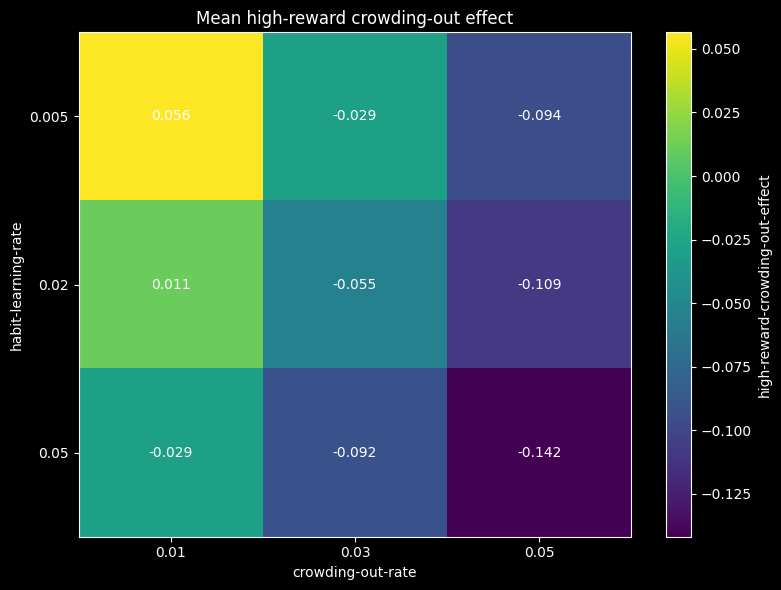

crowding-out-rate,0.01,0.03,0.05
habit-learning-rate,,,
0.005,0.056484,-0.029313,-0.094292
0.020,0.010935,-0.054511,-0.109105
0.050,-0.028942,-0.092040,-0.141798


In [14]:
pivot = clean_df.pivot_table(
    values=PRIMARY_TARGET,
    index="habit-learning-rate",
    columns="crowding-out-rate",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("crowding-out-rate")
ax.set_ylabel("habit-learning-rate")
ax.set_title("Mean high-reward crowding-out effect")

for row in range(pivot.shape[0]):
    for column in range(pivot.shape[1]):
        ax.text(column, row, f"{pivot.iloc[row, column]:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label=PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_habit_vs_crowding.png", dpi=200)
plt.show()

pivot

## Heatmap: high reward × crowding-out

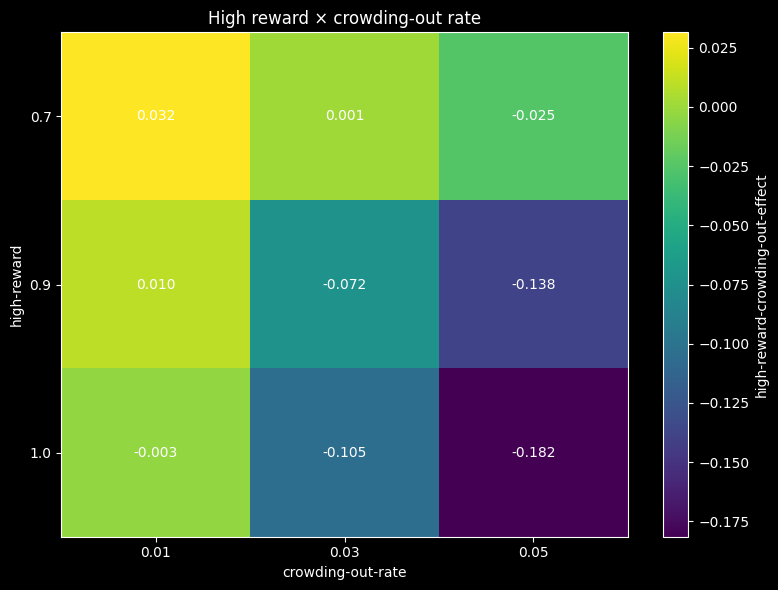

crowding-out-rate,0.01,0.03,0.05
high-reward,,,
0.7,0.031528,0.001335,-0.025277
0.9,0.009996,-0.072256,-0.138373
1.0,-0.003046,-0.104943,-0.181546


In [15]:
pivot_reward = clean_df.pivot_table(
    values=PRIMARY_TARGET,
    index="high-reward",
    columns="crowding-out-rate",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(pivot_reward.values, aspect="auto")

ax.set_xticks(range(len(pivot_reward.columns)))
ax.set_xticklabels(pivot_reward.columns)
ax.set_yticks(range(len(pivot_reward.index)))
ax.set_yticklabels(pivot_reward.index)
ax.set_xlabel("crowding-out-rate")
ax.set_ylabel("high-reward")
ax.set_title("High reward × crowding-out rate")

for row in range(pivot_reward.shape[0]):
    for column in range(pivot_reward.shape[1]):
        ax.text(column, row, f"{pivot_reward.iloc[row, column]:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label=PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_high_reward_vs_crowding.png", dpi=200)
plt.show()

pivot_reward

## Interaction plot

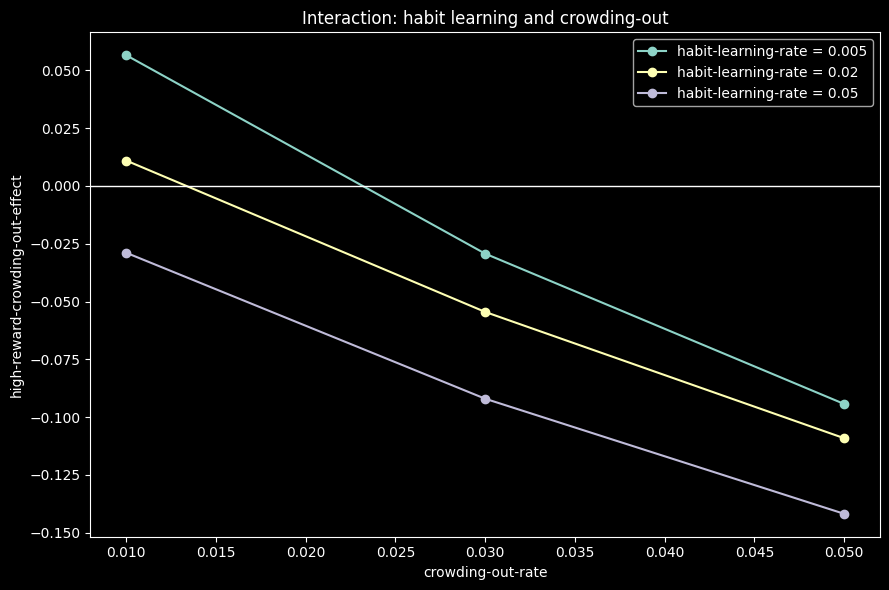

In [16]:
interaction = (
    clean_df.groupby(["crowding-out-rate", "habit-learning-rate"])[PRIMARY_TARGET]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

for habit_rate in sorted(interaction["habit-learning-rate"].unique()):
    subset = interaction[interaction["habit-learning-rate"] == habit_rate]
    ax.plot(
        subset["crowding-out-rate"],
        subset[PRIMARY_TARGET],
        marker="o",
        label=f"habit-learning-rate = {habit_rate}",
    )

ax.axhline(0, linewidth=1)
ax.set_title("Interaction: habit learning and crowding-out")
ax.set_xlabel("crowding-out-rate")
ax.set_ylabel(PRIMARY_TARGET)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "interaction_habit_crowding.png", dpi=200)
plt.show()

## Factorial ANOVA

Параметри трактуються як категоріальні фактори. Модель включає головні ефекти й усі двофакторні взаємодії.

In [17]:
anova_df = clean_df.rename(columns={
    "low-reward": "low_reward",
    "high-reward": "high_reward",
    "crowding-out-rate": "crowding_out_rate",
    "habit-learning-rate": "habit_learning_rate",
    PRIMARY_TARGET: "crowding_effect",
})

formula = (
    "crowding_effect ~ "
    "C(low_reward) + C(high_reward) + "
    "C(crowding_out_rate) + C(habit_learning_rate) + "
    "C(low_reward):C(high_reward) + "
    "C(low_reward):C(crowding_out_rate) + "
    "C(low_reward):C(habit_learning_rate) + "
    "C(high_reward):C(crowding_out_rate) + "
    "C(high_reward):C(habit_learning_rate) + "
    "C(crowding_out_rate):C(habit_learning_rate)"
)

anova_model = smf.ols(formula, data=anova_df).fit()
anova_table = anova_lm(anova_model, typ=2)
anova_table["eta_squared"] = anova_table["sum_sq"] / anova_table["sum_sq"].sum()
anova_table = anova_table.sort_values("eta_squared", ascending=False)

anova_table.to_csv(OUTPUT_DIR / "factorial_anova.csv")
anova_table

,sum_sq,df,F,PR(>F),eta_squared
C(crowding_out_rate),4.436406,2.0,22768.637221,0.000000e+00,0.474829
C(high_reward),2.790808,2.0,14323.055953,0.000000e+00,0.298700
C(habit_learning_rate),1.154490,2.0,5925.102087,0.000000e+00,0.123565
C(high_reward):C(crowding_out_rate),0.730177,4.0,1873.716029,0.000000e+00,0.078151
Residual,0.154611,1587.0,NaN,NaN,0.016548
C(crowding_out_rate):C(habit_learning_rate),0.074642,4.0,191.538719,4.645161e-134,0.007989
C(high_reward):C(habit_learning_rate),0.001111,4.0,2.851711,2.267494e-02,0.000119
C(low_reward):C(crowding_out_rate),0.000584,4.0,1.499439,1.998797e-01,0.000063
C(low_reward):C(high_reward),0.000139,4.0,0.357889,8.386473e-01,0.000015
C(low_reward):C(habit_learning_rate),0.000139,4.0,0.357041,8.392407e-01,0.000015


## Діагностика ANOVA

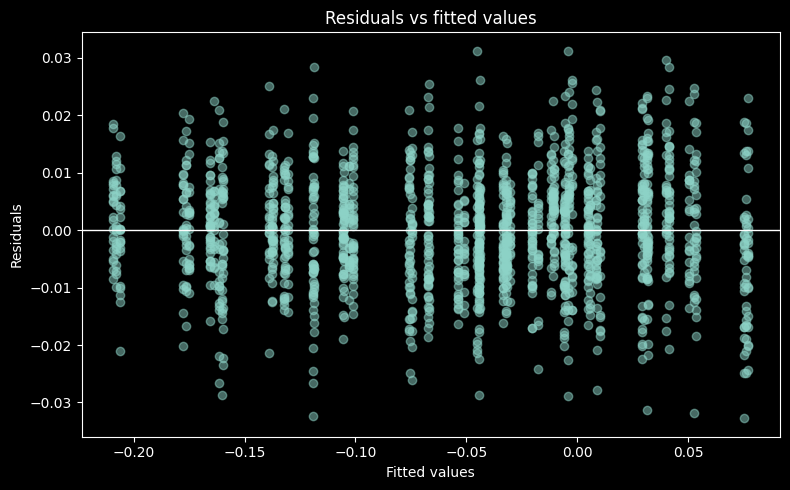

In [18]:
residuals = anova_model.resid
fitted = anova_model.fittedvalues

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, residuals, alpha=0.5)
ax.axhline(0, linewidth=1)
ax.set_title("Residuals vs fitted values")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "anova_residuals_vs_fitted.png", dpi=200)
plt.show()

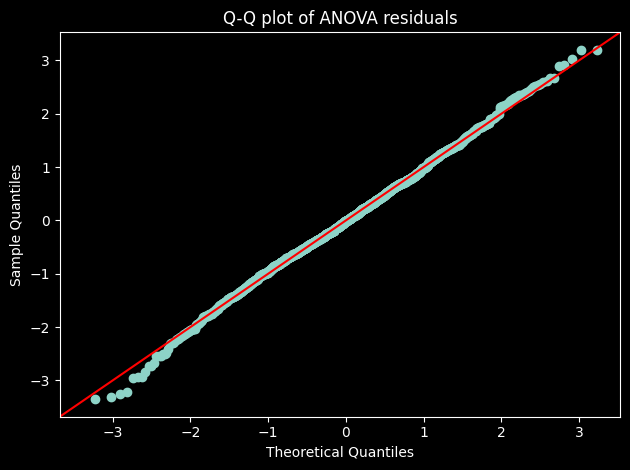

In [19]:
fig = sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q plot of ANOVA residuals")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "anova_residuals_qq.png", dpi=200)
plt.show()

## Random Forest

In [20]:
X = clean_df[PARAMETERS].copy()
y = clean_df[PRIMARY_TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=1,
)

rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

print("R²:", round(r2_score(y_test, predictions), 4))
print("MAE:", round(mean_absolute_error(y_test, predictions), 4))

R²: 0.9825
MAE: 0.0082


## Permutation importance

In [21]:
permutation = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2",
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "parameter": PARAMETERS,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)
importance_df

,parameter,importance_mean,importance_std
2,crowding-out-rate,1.181615,0.067955
1,high-reward,0.715410,0.049260
3,habit-learning-rate,0.264204,0.010685
0,low-reward,-0.000605,0.000357


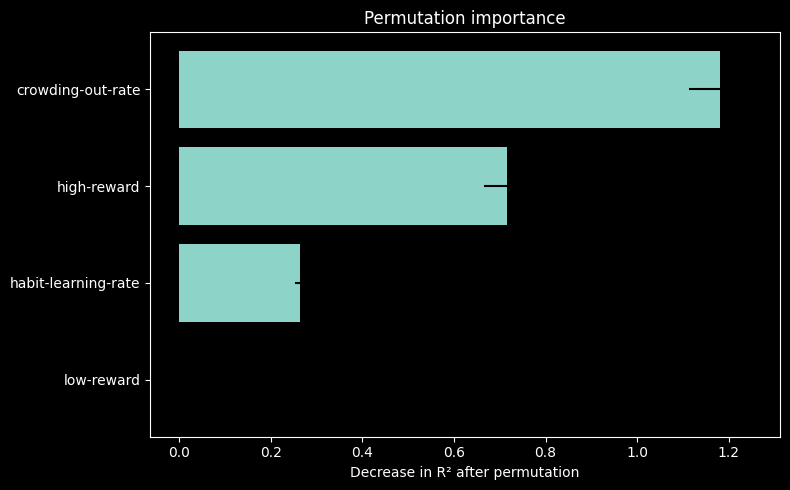

In [22]:
ordered = importance_df.sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    ordered["parameter"],
    ordered["importance_mean"],
    xerr=ordered["importance_std"],
)
ax.set_title("Permutation importance")
ax.set_xlabel("Decrease in R² after permutation")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=200)
plt.show()

## Partial dependence

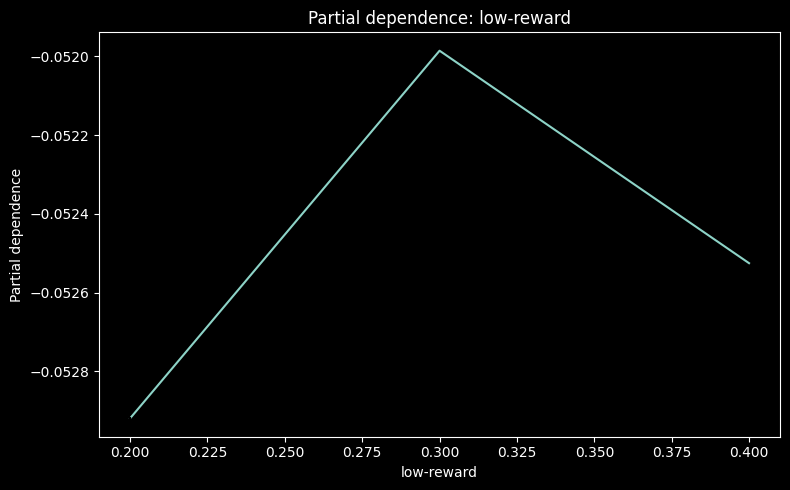

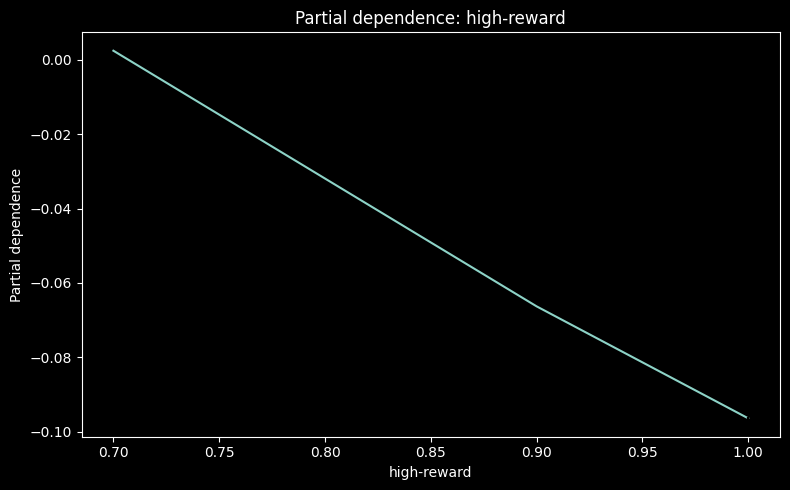

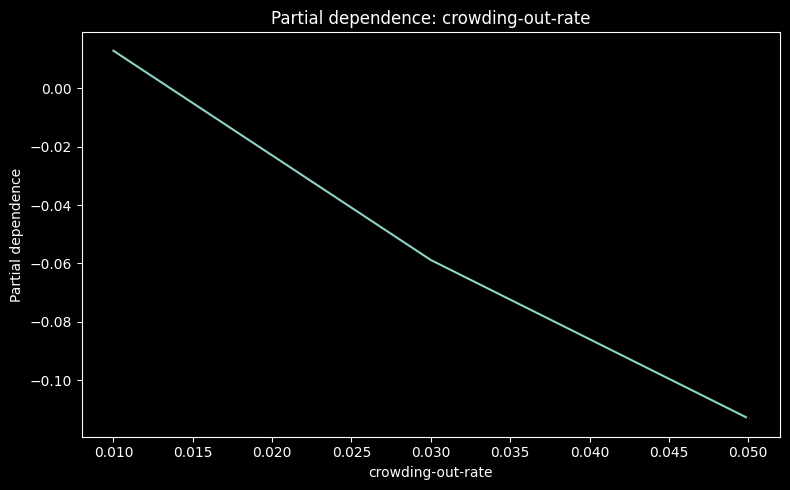

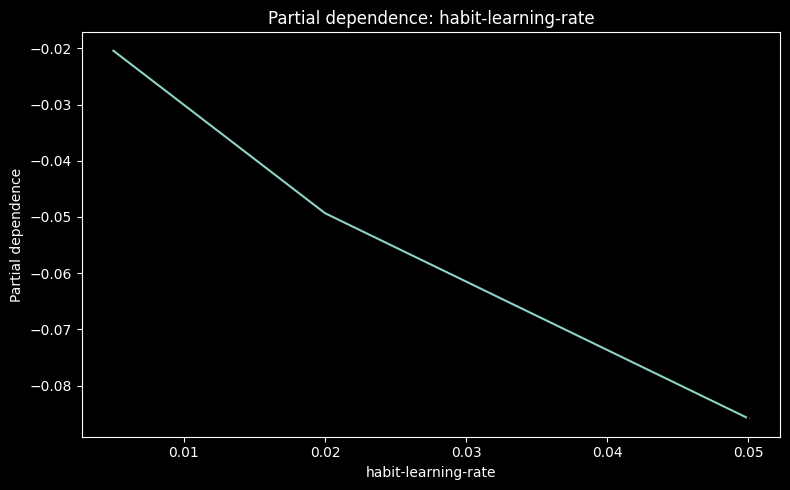

In [23]:
for parameter in PARAMETERS:
    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(
        rf,
        X_train,
        [parameter],
        ax=ax,
    )
    ax.set_title(f"Partial dependence: {parameter}")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"partial_dependence_{parameter}.png",
        dpi=200,
    )
    plt.show()

## Підсумок сценаріїв

In [24]:
scenario_summary = (
    clean_df.groupby(PARAMETERS)
    .agg(
        mean_crowding_effect=(PRIMARY_TARGET, "mean"),
        std_crowding_effect=(PRIMARY_TARGET, "std"),
        mean_low_persistence=(SECONDARY_TARGET, "mean"),
        crowding_probability=(PRIMARY_TARGET, lambda values: (values < 0).mean()),
        runs=(PRIMARY_TARGET, "size"),
    )
    .reset_index()
)

scenario_summary.to_csv(OUTPUT_DIR / "scenario_summary.csv", index=False)

print("Сценарії з найсильнішим crowding-out:")
display(scenario_summary.sort_values("mean_crowding_effect").head(10))

print("Сценарії з найкращою high-reward persistence:")
display(
    scenario_summary
    .sort_values("mean_crowding_effect", ascending=False)
    .head(10)
)

Сценарії з найсильнішим crowding-out:


,low-reward,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,crowding_probability,runs
53,0.3,1.0,0.05,0.050,-0.207303,0.008706,0.029291,1.0,20
80,0.4,1.0,0.05,0.050,-0.206152,0.007253,0.023806,1.0,20
26,0.2,1.0,0.05,0.050,-0.206037,0.007394,0.031936,1.0,20
79,0.4,1.0,0.05,0.020,-0.176350,0.008902,0.055006,1.0,20
25,0.2,1.0,0.05,0.020,-0.176248,0.009998,0.052183,1.0,20
52,0.3,1.0,0.05,0.020,-0.173698,0.008168,0.058481,1.0,20
24,0.2,1.0,0.05,0.005,-0.164262,0.013062,0.060965,1.0,20
71,0.4,0.9,0.05,0.050,-0.164230,0.005915,0.023610,1.0,20
17,0.2,0.9,0.05,0.050,-0.163904,0.006761,0.031729,1.0,20
78,0.4,1.0,0.05,0.005,-0.163759,0.011158,0.075743,1.0,20


Сценарії з найкращою high-reward persistence:


,low-reward,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,crowding_probability,runs
0,0.2,0.7,0.01,0.005,0.073654,0.012744,0.061654,0.0,20
54,0.4,0.7,0.01,0.005,0.070433,0.012329,0.083729,0.0,20
27,0.3,0.7,0.01,0.005,0.068187,0.012487,0.069856,0.0,20
63,0.4,0.9,0.01,0.005,0.054086,0.013665,0.081726,0.0,20
9,0.2,0.9,0.01,0.005,0.053563,0.010645,0.061636,0.0,20
36,0.3,0.9,0.01,0.005,0.052109,0.009275,0.069714,0.0,20
72,0.4,1.0,0.01,0.005,0.046135,0.008976,0.082561,0.0,20
45,0.3,1.0,0.01,0.005,0.045370,0.012024,0.073516,0.0,20
18,0.2,1.0,0.01,0.005,0.044821,0.010587,0.064648,0.0,20
30,0.3,0.7,0.03,0.005,0.034541,0.010009,0.070805,0.0,20


## Стабільний crowding-out

In [25]:
stable_crowding = (
    scenario_summary[
        (scenario_summary["mean_crowding_effect"] < 0)
        & (scenario_summary["crowding_probability"] >= 0.80)
    ]
    .sort_values(
        ["crowding_probability", "mean_crowding_effect"],
        ascending=[False, True],
    )
)

print("Кількість сценаріїв із crowding-out у ≥80% повторень:", len(stable_crowding))
stable_crowding.head(20)

Кількість сценаріїв із crowding-out у ≥80% повторень: 56


,low-reward,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,crowding_probability,runs
53,0.3,1.0,0.05,0.050,-0.207303,0.008706,0.029291,1.0,20
80,0.4,1.0,0.05,0.050,-0.206152,0.007253,0.023806,1.0,20
26,0.2,1.0,0.05,0.050,-0.206037,0.007394,0.031936,1.0,20
79,0.4,1.0,0.05,0.020,-0.176350,0.008902,0.055006,1.0,20
25,0.2,1.0,0.05,0.020,-0.176248,0.009998,0.052183,1.0,20
52,0.3,1.0,0.05,0.020,-0.173698,0.008168,0.058481,1.0,20
24,0.2,1.0,0.05,0.005,-0.164262,0.013062,0.060965,1.0,20
71,0.4,0.9,0.05,0.050,-0.164230,0.005915,0.023610,1.0,20
17,0.2,0.9,0.05,0.050,-0.163904,0.006761,0.031729,1.0,20
78,0.4,1.0,0.05,0.005,-0.163759,0.011158,0.075743,1.0,20


## Порівняння withdrawal-груп

In [26]:
withdrawal_summary = clean_df[WITHDRAWAL_RATES].agg(["mean", "std", "median"]).T
withdrawal_summary["ci95"] = (
    1.96 * clean_df[WITHDRAWAL_RATES].std() / np.sqrt(len(clean_df))
)

withdrawal_summary.to_csv(OUTPUT_DIR / "withdrawal_group_summary.csv")
withdrawal_summary

,mean,std,median,ci95
"choice-rate ""control"" ""withdrawal""",0.697487,0.103758,0.741168,0.005053
"choice-rate ""low-salience"" ""withdrawal""",0.749065,0.087694,0.796446,0.004270
"choice-rate ""high-salience"" ""withdrawal""",0.643867,0.106338,0.640916,0.005178


## Коротке автоматичне резюме

In [27]:
print("Середній high-reward crowding-out effect:", round(clean_df[PRIMARY_TARGET].mean(), 4))
print("Середній low-reward persistence effect:", round(clean_df[SECONDARY_TARGET].mean(), 4))
print("Частка запусків із crowding-out:", f"{crowding_share:.1%}")
print("Найважливіший параметр за permutation importance:", importance_df.iloc[0]["parameter"])
print("Найбільший ефект за ANOVA eta²:", anova_table.index[0])

Середній high-reward crowding-out effect: -0.0536
Середній low-reward persistence effect: 0.0516
Частка запусків із crowding-out: 72.5%
Найважливіший параметр за permutation importance: crowding-out-rate
Найбільший ефект за ANOVA eta²: C(crowding_out_rate)


## Рекомендації для другого експерименту

Зверни увагу на:

- фактор із найбільшим `eta_squared`;
- параметр із найбільшою permutation importance;
- найсильнішу двофакторну взаємодію;
- heatmap-ділянки, де ефект змінює знак;
- сценарії з `crowding_probability >= 0.80`.

Другий експеримент варто будувати навколо параметрів, які визначають межу між persistence і crowding-out.

## Експорт очищених даних

In [28]:
clean_df.to_csv(OUTPUT_DIR / "clean_experiment_data.csv", index=False)
print("Результати збережено у:", OUTPUT_DIR.resolve())

Результати збережено у: /Users/igor/projects/phd/reward-habits-model/analysis_output


In [35]:
scenario_summary.sort_values(

    "mean_crowding_effect",

    ascending=False

).head(10)

,low-reward,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,crowding_probability,runs
0,0.2,0.7,0.01,0.005,0.073654,0.012744,0.061654,0.0,20
54,0.4,0.7,0.01,0.005,0.070433,0.012329,0.083729,0.0,20
27,0.3,0.7,0.01,0.005,0.068187,0.012487,0.069856,0.0,20
63,0.4,0.9,0.01,0.005,0.054086,0.013665,0.081726,0.0,20
9,0.2,0.9,0.01,0.005,0.053563,0.010645,0.061636,0.0,20
36,0.3,0.9,0.01,0.005,0.052109,0.009275,0.069714,0.0,20
72,0.4,1.0,0.01,0.005,0.046135,0.008976,0.082561,0.0,20
45,0.3,1.0,0.01,0.005,0.045370,0.012024,0.073516,0.0,20
18,0.2,1.0,0.01,0.005,0.044821,0.010587,0.064648,0.0,20
30,0.3,0.7,0.03,0.005,0.034541,0.010009,0.070805,0.0,20


In [36]:
scenario_summary.sort_values(

    "mean_crowding_effect"

).head(10)

,low-reward,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,crowding_probability,runs
53,0.3,1.0,0.05,0.050,-0.207303,0.008706,0.029291,1.0,20
80,0.4,1.0,0.05,0.050,-0.206152,0.007253,0.023806,1.0,20
26,0.2,1.0,0.05,0.050,-0.206037,0.007394,0.031936,1.0,20
79,0.4,1.0,0.05,0.020,-0.176350,0.008902,0.055006,1.0,20
25,0.2,1.0,0.05,0.020,-0.176248,0.009998,0.052183,1.0,20
52,0.3,1.0,0.05,0.020,-0.173698,0.008168,0.058481,1.0,20
24,0.2,1.0,0.05,0.005,-0.164262,0.013062,0.060965,1.0,20
71,0.4,0.9,0.05,0.050,-0.164230,0.005915,0.023610,1.0,20
17,0.2,0.9,0.05,0.050,-0.163904,0.006761,0.031729,1.0,20
78,0.4,1.0,0.05,0.005,-0.163759,0.011158,0.075743,1.0,20


In [37]:
stable_crowding

,low-reward,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,crowding_probability,runs
53,0.3,1.0,0.05,0.050,-0.207303,0.008706,0.029291,1.00,20
80,0.4,1.0,0.05,0.050,-0.206152,0.007253,0.023806,1.00,20
26,0.2,1.0,0.05,0.050,-0.206037,0.007394,0.031936,1.00,20
79,0.4,1.0,0.05,0.020,-0.176350,0.008902,0.055006,1.00,20
25,0.2,1.0,0.05,0.020,-0.176248,0.009998,0.052183,1.00,20
52,0.3,1.0,0.05,0.020,-0.173698,0.008168,0.058481,1.00,20
24,0.2,1.0,0.05,0.005,-0.164262,0.013062,0.060965,1.00,20
71,0.4,0.9,0.05,0.050,-0.164230,0.005915,0.023610,1.00,20
17,0.2,0.9,0.05,0.050,-0.163904,0.006761,0.031729,1.00,20
78,0.4,1.0,0.05,0.005,-0.163759,0.011158,0.075743,1.00,20
